In [1]:
import pandas as pd

vehicles_df = pd.read_csv("vehicles.csv")
display(vehicles_df.head())

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [2]:
df = vehicles_df
df.isnull().sum()/len(df)

id              0.000000
url             0.000000
region          0.000000
region_url      0.000000
price           0.000000
year            0.002823
manufacturer    0.041337
model           0.012362
condition       0.407852
cylinders       0.416225
fuel            0.007058
odometer        0.010307
title_status    0.019308
transmission    0.005988
VIN             0.377254
drive           0.305863
size            0.717675
type            0.217527
paint_color     0.305011
image_url       0.000159
description     0.000164
county          1.000000
state           0.000000
lat             0.015342
long            0.015342
posting_date    0.000159
dtype: float64

In [3]:
# Remove features that have too much variance or are missing in more than 20% of the instances
df.drop(columns=["county", "size", "paint_color", "description", "image_url", "drive", "VIN", "region_url", "url", "id",  "lat", "long", "region", "state", "model", "posting_date"], inplace=True)
df.head()

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,type
0,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Remove out liers in the price
df = df.drop(df.nlargest(columns=["price"], n=8).index)
df.nlargest(columns=["price"], n=8)
df = df.drop(df[df['price'] == 0].index)
print(df[df['price'] == 0].count())

price           0
year            0
manufacturer    0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
type            0
dtype: int64


In [5]:
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 143030 entries, 27 to 426878
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         143030 non-null  int64  
 1   year          143030 non-null  float64
 2   manufacturer  143030 non-null  str    
 3   condition     143030 non-null  str    
 4   cylinders     143030 non-null  str    
 5   fuel          143030 non-null  str    
 6   odometer      143030 non-null  float64
 7   title_status  143030 non-null  str    
 8   transmission  143030 non-null  str    
 9   type          143030 non-null  str    
dtypes: float64(2), int64(1), str(7)
memory usage: 18.2 MB


I think now we have all of the fields we could possibly use. Well we could have done some feature engenieering with description but I don't really want to do nlp with this project. Latitude and longitude seem hard to use. I think I will also drop those for now and just rely on the region. We are going to have a ton of features at the end of the day just because we have so many values that need to be encoded. I want to turn posting date to posting year.

In [6]:
# df = df.sample(n=50000)

In [7]:
X = df.drop(columns=["price"])
# X = df[['year', 'odometer']]
y = df['price']
X.head()

,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,type
27,2014.0,gmc,good,8 cylinders,gas,57923.0,clean,other,pickup
28,2010.0,chevrolet,good,8 cylinders,gas,71229.0,clean,other,pickup
29,2020.0,chevrolet,good,8 cylinders,gas,19160.0,clean,other,pickup
30,2017.0,toyota,good,8 cylinders,gas,41124.0,clean,other,pickup
31,2013.0,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,truck


In [8]:
# X['posting_date'] = pd.to_numeric(X['posting_date'].str[0:4])
X['cylinders'] = pd.to_numeric(X['cylinders'].str.split().str[0], errors='coerce')
X['cylinders'].describe()

count    142631.000000
mean          6.021664
std           1.571389
min           3.000000
25%           4.000000
50%           6.000000
75%           8.000000
max          12.000000
Name: cylinders, dtype: float64

In [9]:
# One Hot Encoding
X = pd.get_dummies(X, columns=[ "manufacturer", "fuel", "title_status", "transmission", "type", "condition"])
X.head()

,year,cylinders,odometer,manufacturer_acura,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,...,type_sedan,type_truck,type_van,type_wagon,condition_excellent,condition_fair,condition_good,condition_like new,condition_new,condition_salvage
27,2014.0,8.0,57923.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
28,2010.0,8.0,71229.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
29,2020.0,8.0,19160.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
30,2017.0,8.0,41124.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
31,2013.0,6.0,128000.0,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False


In [10]:
X.columns

Index(['year', 'cylinders', 'odometer', 'manufacturer_acura',
       'manufacturer_alfa-romeo', 'manufacturer_aston-martin',
       'manufacturer_audi', 'manufacturer_bmw', 'manufacturer_buick',
       'manufacturer_cadillac', 'manufacturer_chevrolet',
       'manufacturer_chrysler', 'manufacturer_datsun', 'manufacturer_dodge',
       'manufacturer_ferrari', 'manufacturer_fiat', 'manufacturer_ford',
       'manufacturer_gmc', 'manufacturer_harley-davidson',
       'manufacturer_honda', 'manufacturer_hyundai', 'manufacturer_infiniti',
       'manufacturer_jaguar', 'manufacturer_jeep', 'manufacturer_kia',
       'manufacturer_land rover', 'manufacturer_lexus', 'manufacturer_lincoln',
       'manufacturer_mazda', 'manufacturer_mercedes-benz',
       'manufacturer_mercury', 'manufacturer_mini', 'manufacturer_mitsubishi',
       'manufacturer_morgan', 'manufacturer_nissan', 'manufacturer_pontiac',
       'manufacturer_porsche', 'manufacturer_ram', 'manufacturer_rover',
       'manufacturer_

price           0
year            0
manufacturer    0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
type            0
dtype: int64


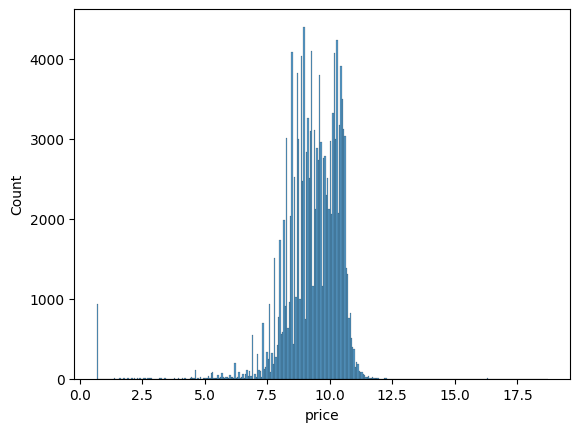

In [11]:
import seaborn as sns
import numpy as np
print(df[df['price'] == 0].count())
sns.histplot(np.log1p(y))
y = np.log1p(y)

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    # ('pca', PCA(n_components=10))  # Specify how many dimensions you want
])
X = pipe.fit_transform(X)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [14]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,        # Number of boosting rounds (trees)
    max_depth=6,             # Maximum depth of each tree (keeps them relatively shallow)
    learning_rate=0.05,      # How much each tree contributes to the overall prediction
    subsample=0.8,           # Use 80% of rows per tree (prevents overfitting)
    colsample_bytree=0.8,    # Use 80% of columns per tree (fights the curse of dimensionality)
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [15]:
print("Train")
print(mean_squared_error(y_train, y_pred= xgb_model.predict(X_train)) )
print(xgb_model.score(X_train, y_train))
print("Test")
test_r2 = mean_squared_error(y_test,  y_pred=xgb_model.predict(X_test))
print(test_r2)
print(xgb_model.score(X_test, y_test))

Train
0.350310392907254
0.7506863027373915
Test
0.49375208272042553
0.651911385211285


In [16]:
import joblib

joblib.dump(pipe, "scaler.joblib")
xgb_model.save_model('xgb_car_predict_model.json')